In [29]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt

from physion.analysis import tools

sys.path.append('../scripts')
from distinct_rest_vs_active import compute_high_movement_cond

import random

In [30]:
def plot_behavior_in_episodes(data,
                              ax=None,
                              running_speed_threshold=0.1,
                              pupil_threshold=2.9, 
                              metric=None):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(2,1.3))
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
    else:
        fig = None

    HAcount, LAcount = [], []
    for p, protocol in enumerate(protocols):
        try:
            
            behav_episodes = EpisodeData(data, 
                                 quantities=['dFoF', 'Pupil', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
        except:
            try: 
                behav_episodes = EpisodeData(data, 
                                 quantities=['dFoF', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
            except: 
                print("error when computing behavioral episodes")

        
        # HAcond: high arousal condition
        HAcond = compute_high_movement_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric=metric)
            
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[~HAcond],
                behav_episodes.running_speed.mean(axis=1)[~HAcond], 'o', color='grey')
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[HAcond],
                behav_episodes.running_speed.mean(axis=1)[HAcond], 'o', color='orangered')
        
        HAcount.append(np.sum(HAcond))
        LAcount.append(np.sum(~HAcond))
        
    ax.set_ylabel('run. speed (cm/s)')
    ax.set_xlabel('pupil size (mm)')
    ax.annotate('\n n=%i ep.' % np.sum(HAcount), (0, 1), color='orangered', xycoords='axes fraction', va='top')
    ax.annotate(' n=%i ep.' % np.sum(LAcount), (0, 1), color='grey', xycoords='axes fraction', va='top')
    
    return fig, ax

In [31]:
def plot_dFoF_locomotion_all(all_episodes, 
                         all_HMcond, 
                         roi_n=None, 
                         episode_n = None, 
                         general=True, 
                         active=True, 
                         resting=True):
    
    fig, AX = plt.subplots(2, 1, figsize=(4, 2)) 
    fig.subplots_adjust(hspace=0.8)

    if episode_n is None: #average of all episodes 
        num_epi_all = 0
        for i in range(len(all_episodes)):
            temp = all_episodes[i].dFoF.shape[0]
            num_epi_all += temp
        print(np.sum(all_HMcond))
        print(f"average of {num_epi_all} episodes ({np.sum(all_HMcond)} active, {len(all_HMcond)-np.sum(all_HMcond)} resting)")
        if roi_n is None:
            num_roi_all = 0
            for j in range(len(all_episodes)):
                temp = all_episodes[j].dFoF.shape[1]
                num_roi_all += temp
            print(f"average of {num_roi_all} ROIs")
            
            if general:
                AX[0].plot(ep.t, ep.dFoF[:, :, :].mean(axis=0).mean(axis=0), color='blue') 
                AX[1].plot(ep.t, ep.running_speed[:, :].mean(axis=0), color='blue')
            if active: 
                AX[0].plot(ep.t, ep.dFoF[HMcond, :, :].mean(axis=0).mean(axis=0), color='orangered') 
                AX[1].plot(ep.t, ep.running_speed[HMcond, :].mean(axis=0), color="orangered")
            if resting: 
                AX[0].plot(ep.t, ep.dFoF[~HMcond, :, :].mean(axis=0).mean(axis=0), color = 'grey') 
                AX[1].plot(ep.t, ep.running_speed[~HMcond, :].mean(axis=0), color = "grey")
             
        else: 
            print(f"Specific ROI # {roi_n}")
            if general:
                AX[0].plot(ep.t, ep.dFoF[:, roi_n, :].mean(axis=0), color='blue') 
                AX[1].plot(ep.t, ep.running_speed[:, :].mean(axis=0), color='blue')
            if active: 
                AX[0].plot(ep.t, ep.dFoF[HMcond, roi_n, :].mean(axis=0), color='orangered') 
                AX[1].plot(ep.t, ep.running_speed[HMcond, :].mean(axis=0), color="orangered")
            if resting: 
                AX[0].plot(ep.t, ep.dFoF[~HMcond, roi_n, :].mean(axis=0), color = 'grey') 
                AX[1].plot(ep.t, ep.running_speed[~HMcond, :].mean(axis=0), color = "grey")
                
    else: #specific episode
        print(f"Specific episode # {episode_n} ({state})")
        if roi_n is None: 
            print(f"average of {episodes.dFoF.shape[1]} ROIs")
            AX[0].plot(ep.t, ep.dFoF[episode_n, :, :].mean(axis=0), color='blue') 
            AX[1].plot(ep.t, ep.running_speed[episode_n, :], color='blue')
        else: 
            print(f"Specific ROI # {roi_n}")
            AX[0].plot(ep.t, ep.dFoF[episode_n, roi_n, :], color='blue') 
            AX[1].plot(ep.t, ep.running_speed[episode_n, :], color='blue')
            
        

    
    AX[0].axvspan(0, 2, color='lightgrey')
    AX[0].set_ylabel('dFoF')
    AX[0].set_xlabel('time (s)')
    AX[0].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')

    AX[1].axvspan(0, 2, color='lightgrey')
    AX[1].set_ylabel('locomotion (cm/s)')
    AX[1].set_xlabel('time (s)')
    AX[1].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')

    return 0

In [32]:
def plot_average_visually_evoked_activity(data,
                                           roiIndex=None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1,
                                           metric=None, 
                                           with_axis=False):
    
    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(2, 1, figsize=(4, 2), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')
    try :    
        episodes = EpisodeData(data,
                               quantities=['dFoF', 'Pupil', 'Running-Speed'],
                               protocol_name=protocol,
                               prestim_duration=1,
                               verbose=False)
    except: 
        try: 
            episodes = EpisodeData(data,
                               quantities=['dFoF', 'Running-Speed'],
                               protocol_name=protocol,
                               prestim_duration=1,
                               verbose=False)
        except: 
            try: 
                episodes = EpisodeData(data,
                               quantities=['dFoF', 'Pupil'],
                               protocol_name=protocol,
                               prestim_duration=1,
                               verbose=False)
            except : 
                print("behavioral data missing")

    
    
    HMcond = compute_high_movement_cond(episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
    #HMcond = compute_high_movement_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric="locomotion")

    
    init_val = episodes.data.dFoF.mean(axis=0)[10631]
    max_val = np.max(episodes.data.dFoF.mean(axis=0))
    vdFoF = max_val - init_val
    
    
    #rest trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(~HMcond),
                       with_std=False, with_stim=False,
                       color='grey',
                       AX=[[AX[0][0]]], 
                       no_set=True, 
                       with_axis=with_axis)
       
    #running trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(HMcond),
                       with_std=False, with_stim=True,
                       color='orangered',
                       AX=[[AX[0][0]]], 
                       no_set=True, 
                       with_axis=with_axis)

    AX[0][0].set_xlabel("Time (0.5 ms)? check")
    AX[0][0].set_ylabel("dFoF ")
    
    #inset
    inset = pt.inset(AX[0][0], [0.55, 0.9, 0.3, 0.2])
    rest = sum(~HMcond)
    run  = sum(HMcond)
    inset.pie([rest, run], 
               autopct='%1.1f%%', 
               colors = ['grey', 'orangered'], 
               textprops={'fontsize': 5}, 
               pctdistance=2  )  # Move percentage text closer to the edge
    
    RESULTS['significant'].append([])
    RESULTS['response'].append([])
    RESULTS['session'].append([])
        

    if roiIndex is None:
        AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[0][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 1.2), xycoords='axes fraction')


    #plot traces running speed
    
    AX[1][0].plot(np.arange(0,len(episodes.running_speed[0]),1), episodes.running_speed[~HMcond][roiIndex], color= 'grey')
    AX[1][0].plot(np.arange(0,len(episodes.running_speed[0]),1), episodes.running_speed[HMcond][roiIndex], color= 'orangered')
    AX[1][0].set_xlabel("Time (0.5 ms)? check")
    AX[1][0].set_ylabel("Speed (cm/s)")

    
    return fig

<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:90: SyntaxWarning: invalid escape sequence '\p'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_14984\3412645933.py:90: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


In [33]:
def plot_average_visually_evoked_activity_(data,
                                           roiIndex=None,
                                           spe_episode = None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1,
                                           metric=None, 
                                           with_axis=False):
    
    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(2, 1, figsize=(4, 2), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')

    if spe_episode is not None: 
        print("only 1 episode")

    else: 
        try :    
            episodes = EpisodeData(data,
                                   quantities=['dFoF', 'Pupil', 'Running-Speed'],
                                   protocol_name=protocol,
                                   prestim_duration=1,
                                   verbose=False)
        except: 
            try: 
                episodes = EpisodeData(data,
                                   quantities=['dFoF', 'Running-Speed'],
                                   protocol_name=protocol,
                                   prestim_duration=1,
                                   verbose=False)
            except: 
                try: 
                    episodes = EpisodeData(data,
                                   quantities=['dFoF', 'Pupil'],
                                   protocol_name=protocol,
                                   prestim_duration=1,
                                   verbose=False)
                except : 
                    print("behavioral data missing")
    
        
        
        HMcond = compute_high_movement_cond(episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
        #HMcond = compute_high_movement_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
    
        
        init_val = episodes.data.dFoF.mean(axis=0)[10631]
        max_val = np.max(episodes.data.dFoF.mean(axis=0))
        vdFoF = max_val - init_val
        
        
        #rest trace
        plot_trial_average(episodes, 
                           roiIndex=roiIndex,
                           condition=(~HMcond),
                           with_std=False, with_stim=False,
                           color='grey',
                           AX=[[AX[0][0]]], 
                           no_set=True, 
                           with_axis=with_axis)
           
        #running trace
        plot_trial_average(episodes, 
                           roiIndex=roiIndex,
                           condition=(HMcond),
                           with_std=False, with_stim=True,
                           color='orangered',
                           AX=[[AX[0][0]]], 
                           no_set=True, 
                           with_axis=with_axis)
    
        AX[0][0].set_xlabel("Time (0.5 ms)? check")
        AX[0][0].set_ylabel("dFoF ")
        
        #inset
        inset = pt.inset(AX[0][0], [0.55, 0.9, 0.3, 0.2])
        rest = sum(~HMcond)
        run  = sum(HMcond)
        inset.pie([rest, run], 
                   autopct='%1.1f%%', 
                   colors = ['grey', 'orangered'], 
                   textprops={'fontsize': 5}, 
                   pctdistance=2  )  # Move percentage text closer to the edge
        
        RESULTS['significant'].append([])
        RESULTS['response'].append([])
        RESULTS['session'].append([])
            
    
        if roiIndex is None:
            AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                            data.filename.replace('.nwb',''),data.nROIs),
                               (0, 0),
                              xycoords='axes fraction')
        else:
            AX[0][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                               (0, 1.2), xycoords='axes fraction')
    
    
        #plot traces running speed
        
        AX[1][0].plot(episodes.t, episodes.running_speed[~HMcond][roiIndex], color= 'grey')
        AX[1][0].plot(episodes.t, episodes.running_speed[HMcond][roiIndex], color= 'orangered')
        AX[1][0].set_xlabel("Time (s)")
        AX[1][0].set_ylabel("Speed (cm/s)")

    
    return fig

<>:96: SyntaxWarning: invalid escape sequence '\p'
<>:96: SyntaxWarning: invalid escape sequence '\p'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_14984\983190071.py:96: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


In [34]:
def plot_average_visually_evoked_activity_NDNF(data,
                                           roiIndex=None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1, 
                                           metric=None):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    # prepare array for final results (averaged over sessions)
    RESULTS = {}
    for protocol in protocols:
        RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


    fig, AX = plt.subplots(5, len(protocols),
                              figsize=(7,5))
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HMcond: high movement condition
        HMcond = compute_high_movement_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric=metric)
        
        episodes = EpisodeData(data,
                               quantities=['dFoF'],
                               protocol_name=protocol,
                               verbose=False)
        varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
        varied_values = [episodes.varied_parameters[k] for k in varied_keys]

        AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                          (0.5,1.4),
                          xycoords='axes fraction', ha='center')

        i=0
        for values in itertools.product(*varied_values):

            stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)

            #inset
            inset = pt.inset(AX[i][p], [0.55, 0.9, 0.3, 0.2])
            rest = sum(stim_cond & (~HMcond))
            run  = sum(stim_cond & HMcond)
            inset.pie([rest, run], 
                       autopct='%1.1f%%', 
                       colors = ['grey', 'orangered'], 
                       textprops={'fontsize': 5}, 
                       #labeldistance=0.5)  # Move labels outside
                       pctdistance=2  )  # Move percentage text closer to the edge

            #rest trace
            if np.sum(~HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & (~HMcond),
                                   with_std=False, with_stim=False,
                                   color='grey',
                                   AX=[[AX[i][p]]], no_set=True)
            #running trace
            if np.sum(HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & HMcond,
                                   with_std=False, with_stim=True,
                                   color='orangered',
                                   AX=[[AX[i][p]]], no_set=True)

            RESULTS[protocol]['significant'].append([])
            RESULTS[protocol]['response'].append([])
            RESULTS[protocol]['session'].append([])
            i+=1

    if roiIndex is None:
        AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[-1][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 0), xycoords='axes fraction')

    pt.set_common_ylims(AX)
    for ax in pt.flatten(AX):
        ax.axis('off')
        if np.isfinite(ax.dataLim.x0) and ax==AX[0][0]:
            pt.draw_bar_scales(ax,
                               Xbar=1., Xbar_label='1s',
                               Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
    pt.set_common_xlims(AX)
    
    return fig

<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\D'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\D'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_14984\4066257144.py:80: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_14984\4066257144.py:94: SyntaxWarning: invalid escape sequence '\D'
  Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)


In [35]:
def plot_dFoF_locomotion(episodes, 
                         HMcond, 
                         roi_n=None, 
                         episode_n = None, 
                         general=True, 
                         active=True, 
                         resting=True):
    
    fig, AX = plt.subplots(2, 1, figsize=(4, 2)) 
    fig.subplots_adjust(hspace=0.8)

    if episode_n is None: #average of all episodes 
        
        print(f"average of {episodes.dFoF.shape[0]} episodes ({np.sum(HMcond)} active, {len(HMcond)-np.sum(HMcond)} resting)")
        if roi_n is None:
            print(f"average of {episodes.dFoF.shape[1]} ROIs")
            if general:
                AX[0].plot(ep.t, ep.dFoF[:, :, :].mean(axis=0).mean(axis=0), color='blue') 
                AX[1].plot(ep.t, ep.running_speed[:, :].mean(axis=0), color='blue')
            if active: 
                AX[0].plot(ep.t, ep.dFoF[HMcond, :, :].mean(axis=0).mean(axis=0), color='orangered') 
                AX[1].plot(ep.t, ep.running_speed[HMcond, :].mean(axis=0), color="orangered")
            if resting: 
                AX[0].plot(ep.t, ep.dFoF[~HMcond, :, :].mean(axis=0).mean(axis=0), color = 'grey') 
                AX[1].plot(ep.t, ep.running_speed[~HMcond, :].mean(axis=0), color = "grey")
             
        else: 
            print(f"Specific ROI # {roi_n}")
            if general:
                AX[0].plot(ep.t, ep.dFoF[:, roi_n, :].mean(axis=0), color='blue') 
                AX[1].plot(ep.t, ep.running_speed[:, :].mean(axis=0), color='blue')
            if active: 
                AX[0].plot(ep.t, ep.dFoF[HMcond, roi_n, :].mean(axis=0), color='orangered') 
                AX[1].plot(ep.t, ep.running_speed[HMcond, :].mean(axis=0), color="orangered")
            if resting: 
                AX[0].plot(ep.t, ep.dFoF[~HMcond, roi_n, :].mean(axis=0), color = 'grey') 
                AX[1].plot(ep.t, ep.running_speed[~HMcond, :].mean(axis=0), color = "grey")
                
    else: #specific episode
        state = ['active' if HMcond[episode_n] else 'resting']
        print(f"Specific episode # {episode_n} ({state})")
        if roi_n is None: 
            print(f"average of {episodes.dFoF.shape[1]} ROIs")
            AX[0].plot(ep.t, ep.dFoF[episode_n, :, :].mean(axis=0), color='blue') 
            AX[1].plot(ep.t, ep.running_speed[episode_n, :], color='blue')
        else: 
            print(f"Specific ROI # {roi_n}")
            AX[0].plot(ep.t, ep.dFoF[episode_n, roi_n, :], color='blue') 
            AX[1].plot(ep.t, ep.running_speed[episode_n, :], color='blue')
            
        

    
    AX[0].axvspan(0, 2, color='lightgrey')
    AX[0].set_ylabel('dFoF')
    AX[0].set_xlabel('time (s)')
    AX[0].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')

    AX[1].axvspan(0, 2, color='lightgrey')
    AX[1].set_ylabel('locomotion (cm/s)')
    AX[1].set_xlabel('time (s)')
    AX[1].annotate('Visual stim', (0.30, 1), color='black', xycoords='axes fraction', va='top')

    return 0

# NDNF 2022

In [36]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]
#SESSIONS[['nwbfiles', 'subjects', 'dates', 'protocols']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 13.3s) 


In [37]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

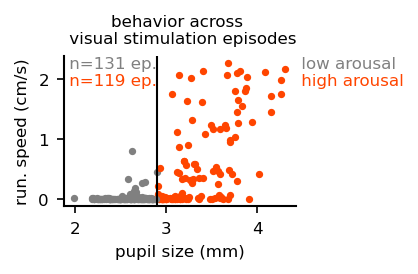

In [38]:
pupil_threshold = 2.9
fig, ax = plot_behavior_in_episodes(data, pupil_threshold=pupil_threshold, metric="pupil")
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')
ax.axvline(x = pupil_threshold, color = 'black', label = 'threshold')

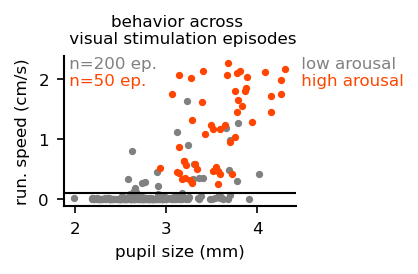

In [39]:
running_speed_threshold=0.1
pupil_threshold = 2.9
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=running_speed_threshold, metric="locomotion")
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')
ax.axhline(running_speed_threshold, color = 'black', label = 'threshold')

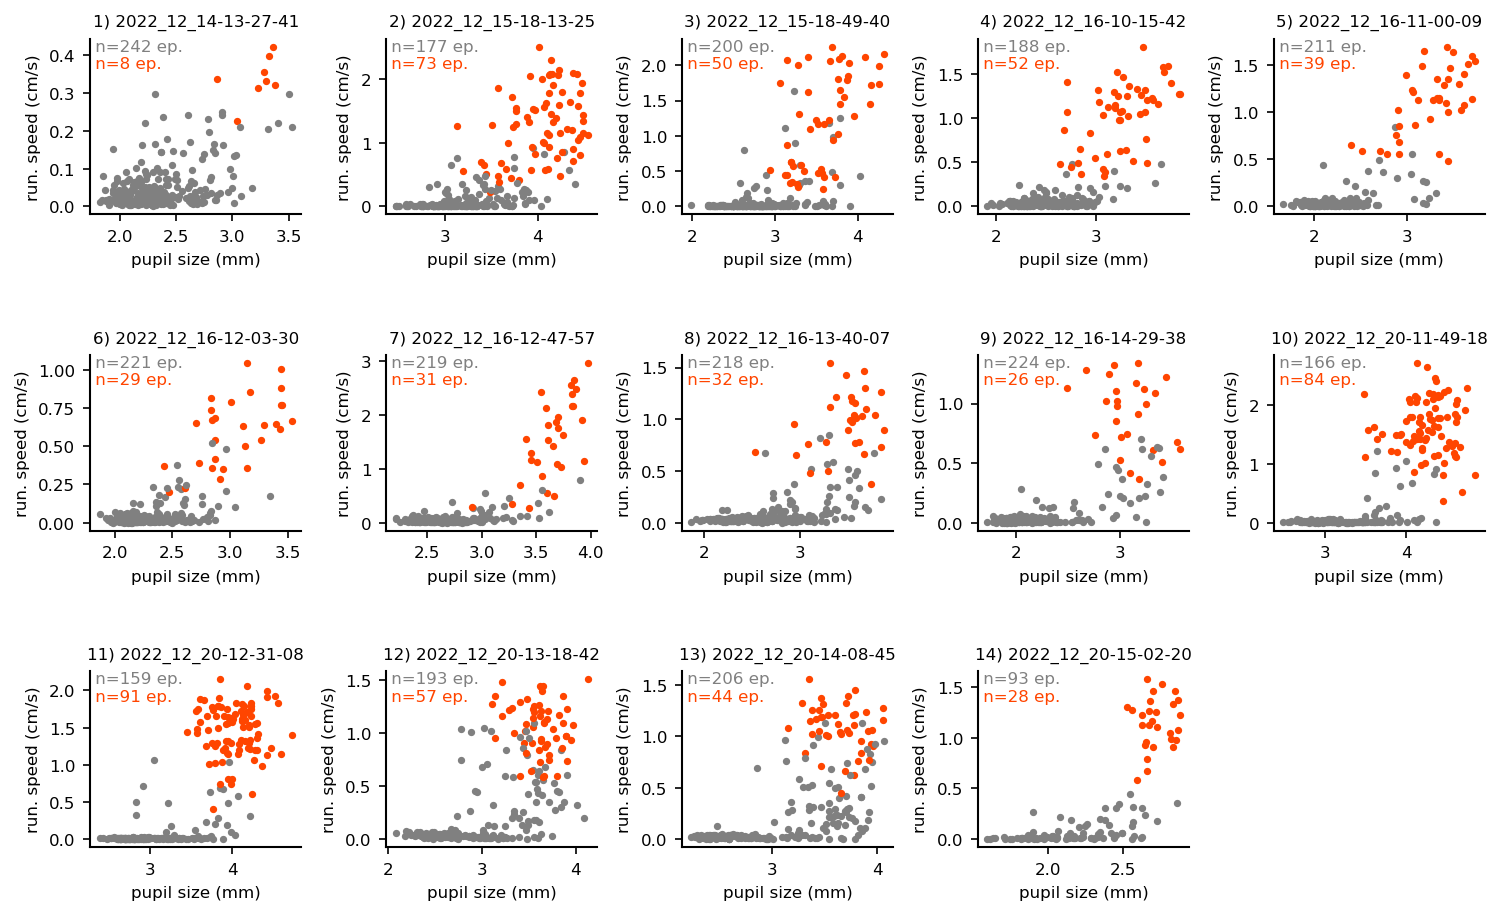

In [40]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='locomotion')
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    

for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

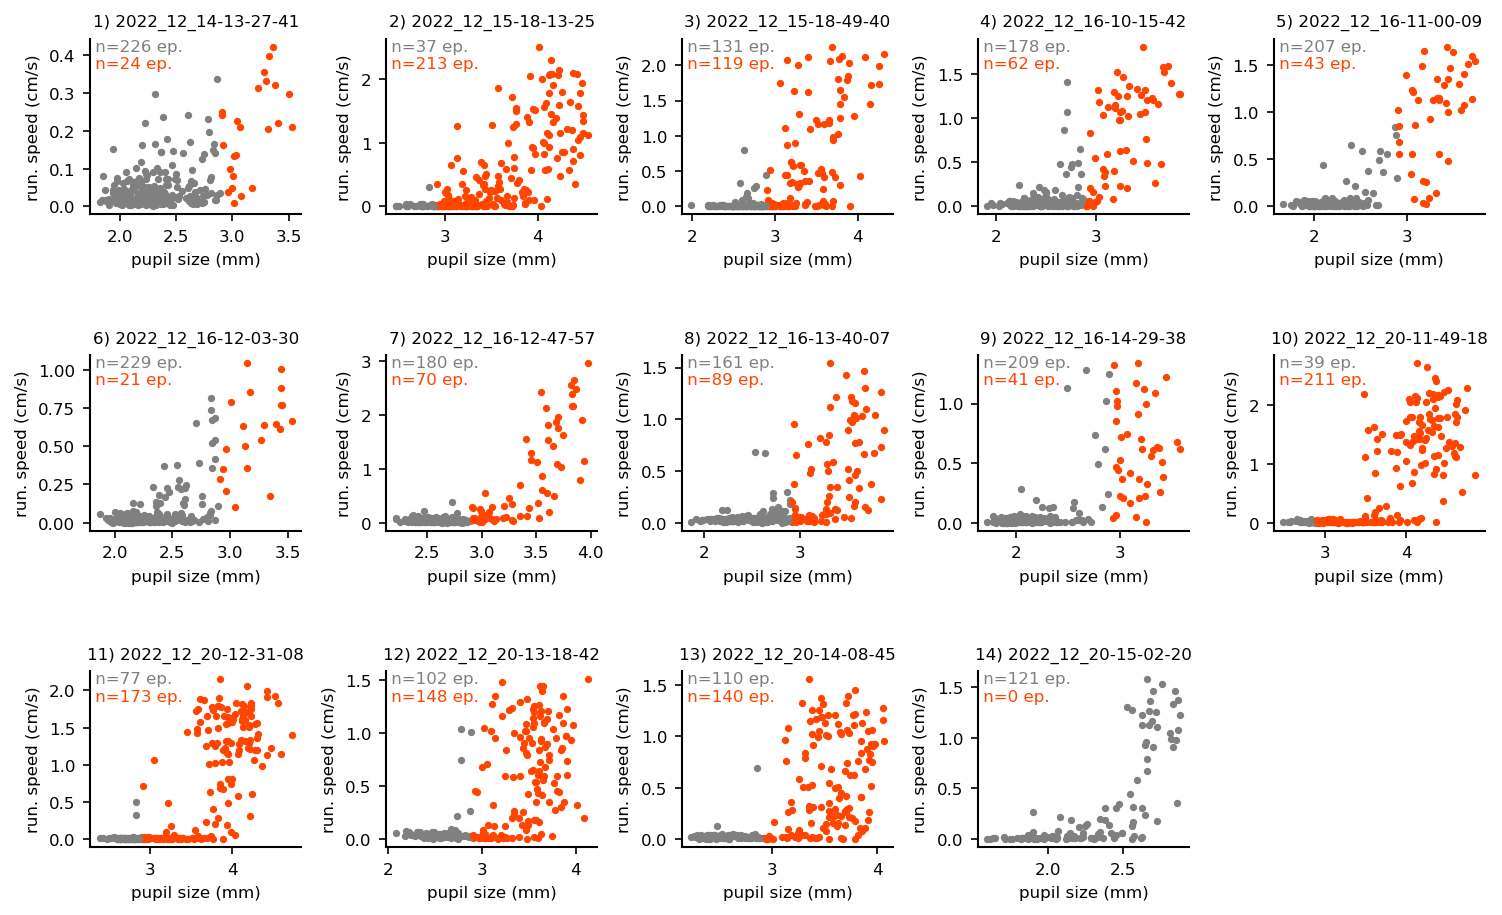

In [41]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='pupil')
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    

for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

In [42]:
protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

STAT_TEST = {}
for protocol in protocols:
    # a default stat test
    STAT_TEST[protocol] = dict(interval_pre=[-1,0],
                               interval_post=[1,2],
                               test='ttest',
                               positive=True)
    
STAT_TEST['looming-stim']['interval_post'] = [2, 3]
STAT_TEST['drifting-gratings']['interval_post'] = [1.5, 2.5]
STAT_TEST['moving-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['random-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['static-patch']['interval_post'] = [0.5, 1.5]

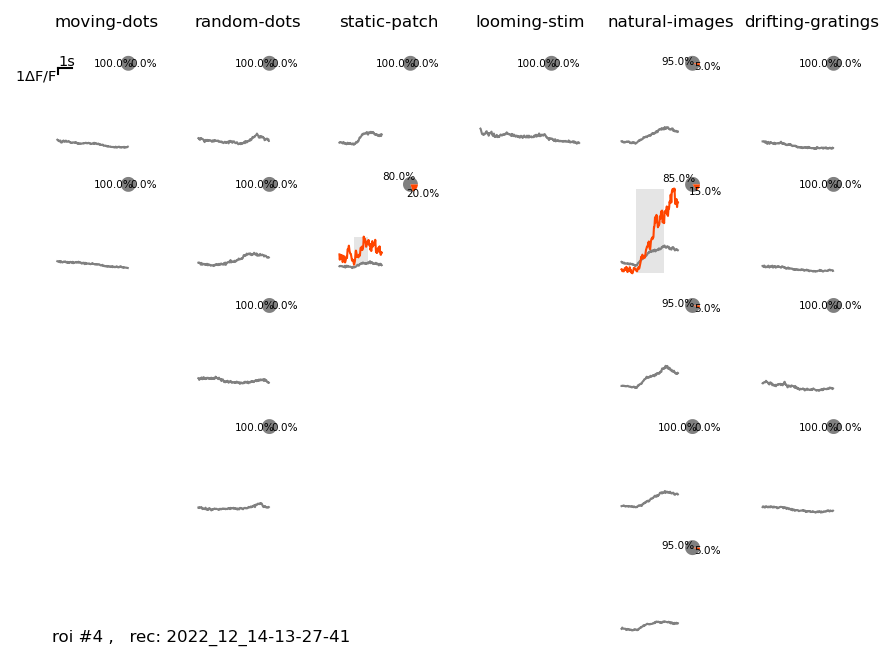

In [43]:
dataIndex, roiIndex = 0, 3
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
fig = plot_average_visually_evoked_activity_NDNF(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

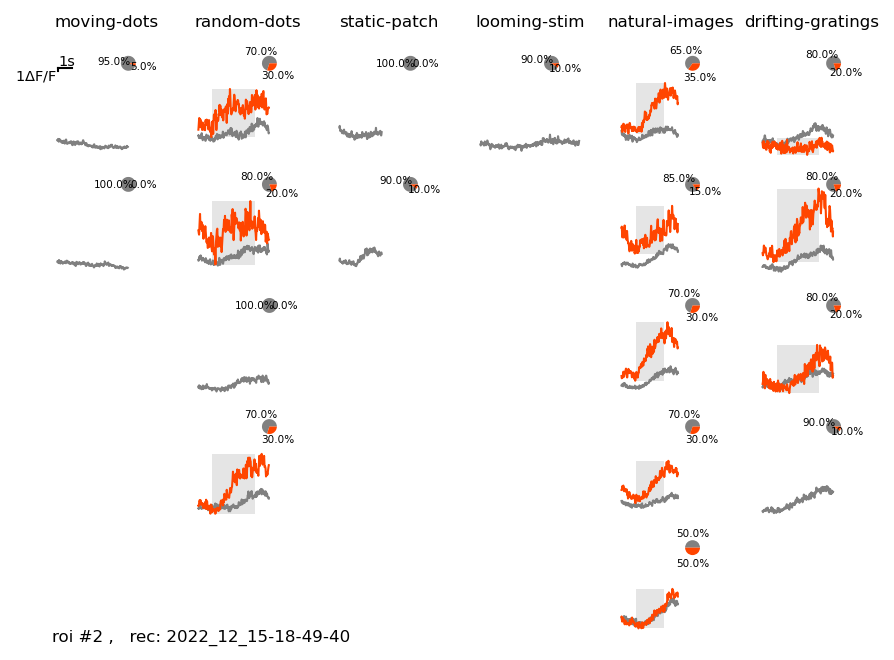

In [44]:
dataIndex, roiIndex = 2, 1
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity_NDNF(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

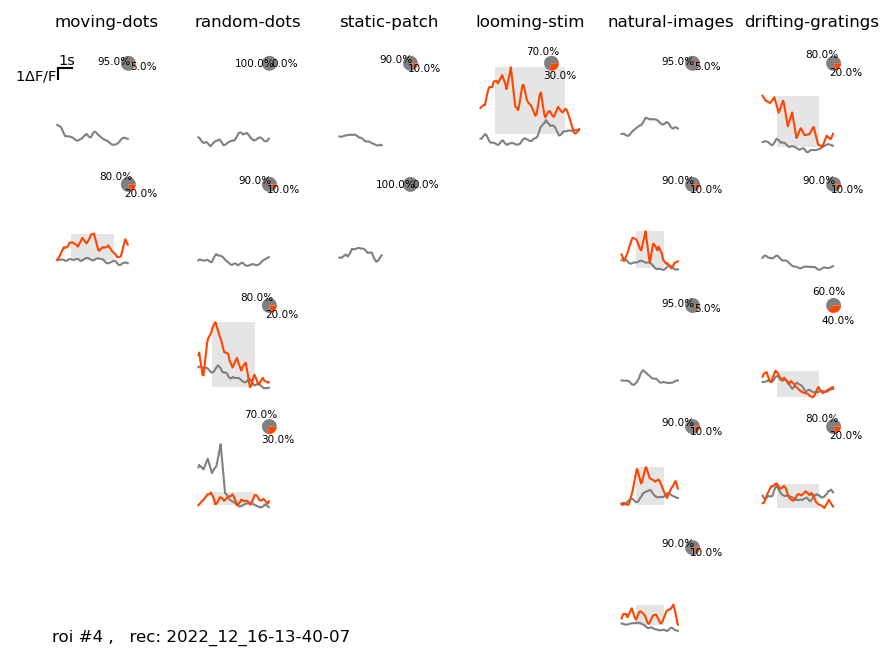

In [45]:
dataIndex, roiIndex = 7, 3
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity_NDNF(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

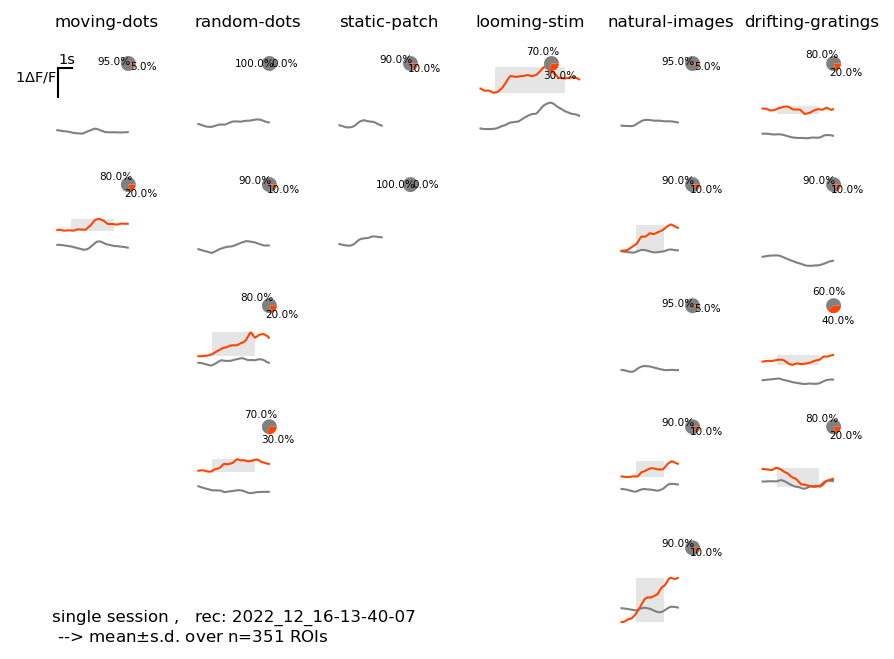

In [46]:
dataIndex, roiIndex = 7, None
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity_NDNF(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')

In [47]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_movement_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !


### Specific ROI, specific episode

Specific episode # 34 (['resting'])
Specific ROI # 260


0

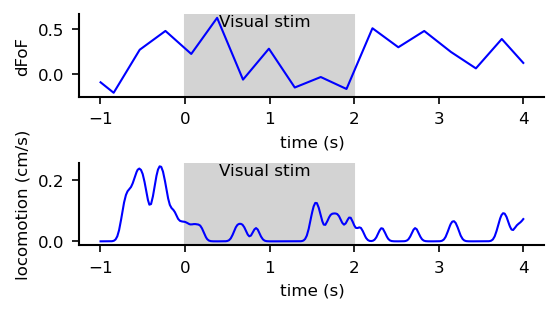

In [48]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

### Specific ROI, average episodes

average of 40 episodes (5 active, 35 resting)
Specific ROI # 140


0

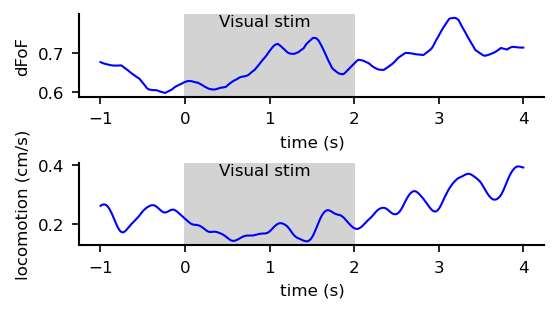

In [49]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

average of 40 episodes (5 active, 35 resting)
Specific ROI # 140


0

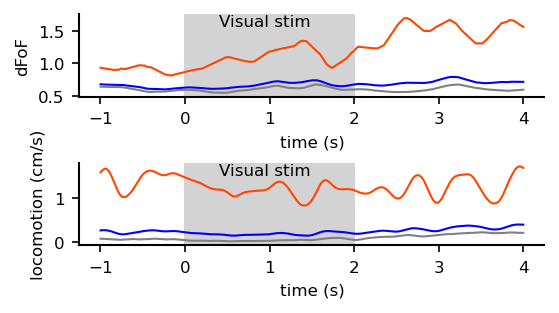

In [50]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

average of 40 episodes (5 active, 35 resting)
Specific ROI # 140


0

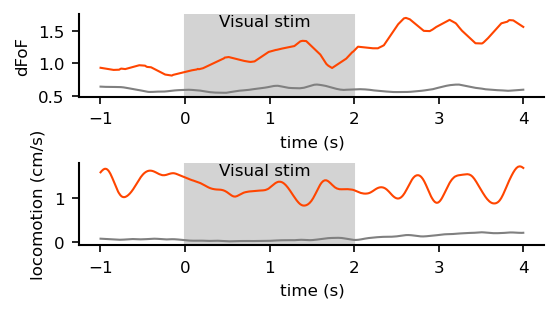

In [51]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Average ROI, average episodes

average of 40 episodes (5 active, 35 resting)
average of 351 ROIs


0

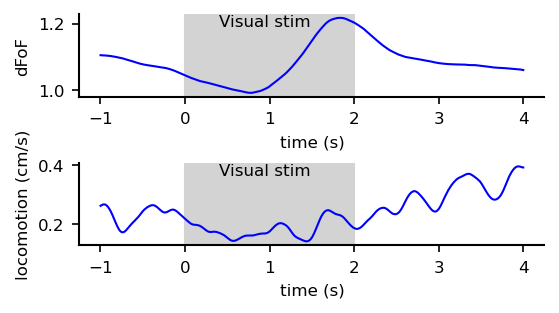

In [52]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

average of 40 episodes (5 active, 35 resting)
average of 351 ROIs


0

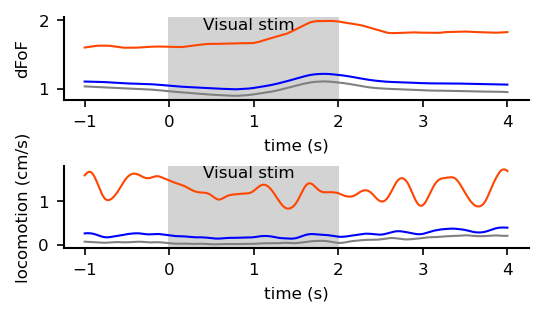

In [53]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

average of 40 episodes (5 active, 35 resting)
average of 351 ROIs


0

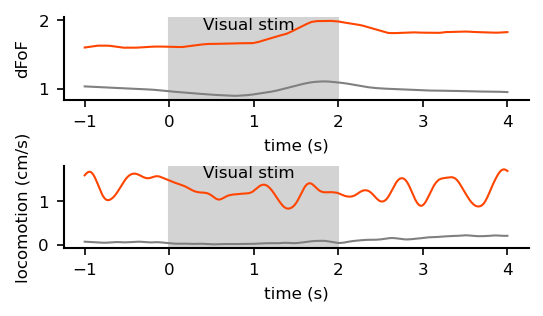

In [54]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### ALL files, average ROI, average episodes

In [55]:
all_ep = []
all_HMcond = []

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])
    all_ep.append(ep)

    HMcond = compute_high_movement_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 39/241 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building epi

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (14,) + inhomogeneous part.

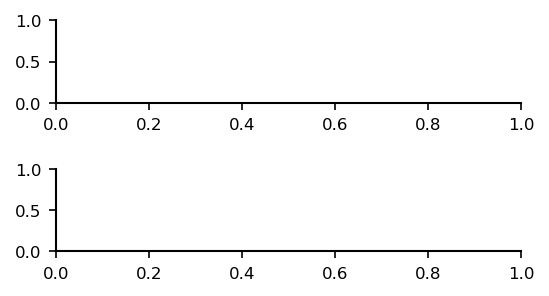

In [56]:
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         roi_n=None, 
                         episode_n = None, 
                         general=True, 
                         active=True, 
                         resting=True)

---------------------

# SST Keta vs Saline Cibele and Sofia 2024-2025

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

In [ ]:
dataIndex = 4
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
data.build_running_speed()
#print(data.pupil_diameter.shape)
print(data.running_speed.shape)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1, metric='locomotion')
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

In [ ]:
rows = 4
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], running_speed_threshold=0.1, metric='locomotion')
    except Exception as e:
        print(f"Error{e}")
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)


for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

In [ ]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_movement_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

### Specific ROI, specific episode

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

### Specific ROI, average episodes

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Average ROI, average episodes

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### ALL files, average ROI, average episodes

In [ ]:
all_ep = []
all_HMcond = []

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])
    all_ep.append(ep)

    HMcond = compute_high_movement_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)

all_HMcond = np.concatenate(all_HMcond)

In [ ]:
print(f"{len(SESSIONS['files'])} files")

plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         roi_n=None, 
                         episode_n = None, 
                         general=True, 
                         active=True, 
                         resting=True)

---

# SST Keta vs Saline Taddy Yann 2023  --- not enough data!!!

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','SST-Ketamine-vs-Saline', 'All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

In [ ]:
dataIndex = 4
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
data.build_running_speed()
data.build_pupil_diameter()
print(data.dFoF.shape)
print(data.pupil_diameter.shape)
print(data.running_speed.shape)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, pupil_threshold = 2.9, running_speed_threshold=0.1, metric='locomotion')
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

In [ ]:
rows = 1
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,2))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[f], running_speed_threshold=0.1, metric='locomotion')
    except Exception as e:
        print(f"Error{e}")
    AX[f].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)

In [ ]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_movement_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

## Useless